In [ ]:
# Imports
import torch  # Main PyTorch library
import torch.nn as nn  # Neural network modules
import torch.optim as optim  # Optimization algorithms
import torch.nn.functional as F  # Activation functions and other functional operations

import numpy as np # For matrix operations

# Data handling imports
from torch.utils.data import Dataset, DataLoader, random_split  # For dataset operations and data loading
from torchvision import datasets, transforms  # For vision datasets and image transformations

# Visualization and utility imports
import matplotlib.pyplot as plt
import numpy as np  # For numerical operations
from tqdm import tqdm  # For progress bars

# PyTorch Lightning wrapper to simplify some of  the process
import pytorch_lightning as pl
import torchmetrics # cleaner metroc calculations
from pytorch_lightning import Trainer, LightningModule
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping # for easier model saving and keeping track of things

In [252]:
# Custom dataset class - From the notebook
class MNISTWithParity(Dataset):
    def __init__(self, mnist_dataset):
        # Initialize the class with the original MNIST dataset
        self.mnist_dataset = mnist_dataset
    
    def __len__(self):
        # Return the length of the dataset
        return len(self.mnist_dataset)
    
    def __getitem__(self, idx):
        # Get an item from the dataset by index
        image, label = self.mnist_dataset[idx]
        
        # Calculate parity (odd/even) of the label
        parity = label % 2  # 0 for even, 1 for odd
        
        # Determine if label is less than 5 or not
        threshold = 0 if label < 5 else 1
        
        # Return the image, and a tuple containing the original label, its parity, and the threshold value
        return image, (label, parity, threshold)

In [ ]:
# Model Architecture - Has some changes, I have removed the comments from the notebook and commented on what I added
class DigitParityCNN(nn.Module):
    def __init__(self):
        super(DigitParityCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        # need to adjust the linear layers if uncommented
        # self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1) # extra layer of conv
        
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2_digit = nn.Linear(256, 10)  # Digit classification (0-9)
        self.fc2_parity = nn.Linear(256, 2)  # Parity classification (odd/even)
        self.fc2_threshold = nn.Linear(256, 2)  # Threshold classification (<5 or >=5)
        
        # Additional layers
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
        # === experimental layers are here ===
        # batch normalization layers for each cnn layer
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        # self.bn4 = nn.BatchNorm2d(256)
        
        # drop out layer for regularization
        # This part could be added to self.save_hyperparameters() on lightning wrapper but it is too much work to comment and comment every time
        self.dropout = nn.Dropout(0.4) 
        # self.avgpool = nn.AdaptiveAvgPool2d((1,1)) disgusting creatue 
        
        # different activations
        self.sigmoid = nn.Sigmoid()
        self.leaky = nn.LeakyReLU(0.2)
        

    def forward(self, x):
        # First convolutional block
        x = self.conv1(x)
        x = self.bn1(x) # normalize before relu
        x = self.relu(x)
        x = self.pool(x)
        
        # Second convolutional block
        x = self.conv2(x)
        x = self.bn2(x) # normalize before relu
        x = self.relu(x)
        x = self.pool(x)
        
        # Third convolutional block
        x = self.conv3(x)
        x = self.bn3(x) # normalize before relu
        x = self.relu(x)
        x = self.pool(x)
        
        # # new forth layer
        # x = self.conv4(x)
        # x = self.bn4(x) # normalize before relu
        # x = self.relu(x)
        # x = self.pool(x)
        
        
        # Flatten the output for the fully connected layers
        x = self.flatten(x)
        
        # this part would replace the last pool and flatten layer
        # Linear layer also needs to be reduced by /3, it is horrible tho dont do it
        # x = self.avgpool(x)
        # x = self.flatten(x)
        
        # First fully connected layer
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)   # randomly drop some neurons, helps with overfitting
        
        # Output layers
        digit_output = self.fc2_digit(x)
        parity_output = self.fc2_parity(x)
        threshold_output = self.fc2_threshold(x)
        
        
        return digit_output, parity_output, threshold_output

In [ ]:
# PyTorch Lightning Module wrapper - All of the different Loss Function, Optimizer, and Scheduler trials are here

'''
I have wrapped some of the bloated parts in here like metrics, loss function, optimizer, and scheduler.
'''
class DigitParityLightning(pl.LightningModule):
    def __init__(self, learning_rate=1e-3, epocs = 10):
        super(DigitParityLightning, self).__init__()
        '''
        save_hyperparameters() is one of the "must have" functions in lightning
        it automatically saves every hyperparameter passed on def __init__ and stores it in self.hparams thats why I used it on optimizers and schedulers
        makes it available when reloading checkpoints as well
        in my case the last part is kind of overkill but since I wanted to simplify the logic of the code, I had to include
        '''
        self.save_hyperparameters()
        self.model = DigitParityCNN()
        self.loss_fn = nn.CrossEntropyLoss()

        '''
        everything is the same as in the notebook in here up until configure optimizers
        '''
        # for easier calculation, I am using torch
        self.acc_digit = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.acc_parity = torchmetrics.Accuracy(task="multiclass", num_classes=2)
        self.acc_threshold = torchmetrics.Accuracy(task="multiclass", num_classes=2)
        
        # same metrics that was in the notebook
        self.train_losses, self.val_losses = [], []
        self.train_digit_acc, self.val_digit_acc = [], []
        self.train_parity_acc, self.val_parity_acc = [], []
        self.train_threshold_acc, self.val_threshold_acc = [], []

    def forward(self, x): # Just using the forward method of the model nothing to change here
        return self.model(x)
    # this is for the metrics and loss. It calculates and logs all the metrics and loss for training and validation then stores it in lightning_logs for future reference
    def _common_step(self, batch, stage): 
        images, (labels, parities, thresholds) = batch # turn  image and label into batch
        digit_out, parity_out, thresh_out = self(images) # outputs from the model

        # Compute total loss
        loss_digit = self.loss_fn(digit_out, labels) # output from the model compared to the labels
        loss_parity = self.loss_fn(parity_out, parities)
        loss_thresh = self.loss_fn(thresh_out, thresholds)
        loss = loss_digit + loss_parity + loss_thresh

        # Compute accuracies
        acc_d = self.acc_digit(digit_out, labels)
        acc_p = self.acc_parity(parity_out, parities)
        acc_t = self.acc_threshold(thresh_out, thresholds)

        # Log everything
        self.log(f"{stage}_loss", loss, prog_bar=True)
        self.log(f"{stage}_digit_acc", acc_d, prog_bar=True)
        self.log(f"{stage}_parity_acc", acc_p, prog_bar=True)
        self.log(f"{stage}_threshold_acc", acc_t, prog_bar=True)

        return loss

    def training_step(self, batch): # just calls the _common_step
        return self._common_step(batch, "train")
    def validation_step(self, batch):
        return self._common_step(batch, "val")

    def configure_optimizers(self):
        # === Optimizers ===
        # optimizer = torch.optim.Adam(self.parameters(), lr=self.lr) 
        optimizer = torch.optim.AdamW(self.parameters(), 
                                      lr=self.hparams.learning_rate, 
                                      weight_decay=0.02, # Helps with overfitting
                                      )
        # optimizer = torch.optim.SGD(self.parameters(), lr=self.hparams.learning_rate, momentum=0.9,) pretty much the same as AdamW but it is kind of inconsistent
        
        # === Schedulers ===
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.9)
        # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max= self.hparams.epocs) # T_max should be the number of epochs
        # scheduler = {
        #     "scheduler": torch.optim.lr_scheduler.ReduceLROnPlateau( # Specifically needs a "monitor" to keep track of the loss and lr
        #         optimizer,
        #         mode="min",       # minimize validation loss
        #         factor=0.2,       # new_lr = lr * factor
        #         patience=3,       # wait 3 epocs without improvement before reducing lr
        #         threshold=0.001, # minimum limit of the lr can be
        #         eps=1e-8 # if the differnce between new and old lr is less than this, then stop updating
        #     ),
        #     "monitor": "val_loss", # what to track
        #     "interval": "epoch", # every epoch
        #     "frequency": 1 # do it once

        return {"optimizer": optimizer, "lr_scheduler": scheduler}
    
    # metric calculations done for the visualization step, moved them here for a cleaner training loop
    # i just took the metrics from the notebook and moved them here so all the appends are done here cleanly
    def on_train_epoch_end(self): 
        self.train_losses.append(self.trainer.callback_metrics['train_loss'].item())
        self.train_digit_acc.append(self.trainer.callback_metrics['train_digit_acc'].item())
        self.train_parity_acc.append(self.trainer.callback_metrics['train_parity_acc'].item())
        self.train_threshold_acc.append(self.trainer.callback_metrics['train_threshold_acc'].item())
    def on_validation_epoch_end(self):
        self.val_losses.append(self.trainer.callback_metrics['val_loss'].item())
        self.val_digit_acc.append(self.trainer.callback_metrics['val_digit_acc'].item())
        self.val_parity_acc.append(self.trainer.callback_metrics['val_parity_acc'].item())
        self.val_threshold_acc.append(self.trainer.callback_metrics['val_threshold_acc'].item())

In [255]:
# Dataloading, preprocessing, and splitting - Just moved valiation split here - 80 20 split
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
custom_dataset = MNISTWithParity(mnist_dataset)

# 80 20 split
validation_split = 0.2 # moved val and batch_size here
train_size = int((1 - validation_split) * len(custom_dataset))
val_size = len(custom_dataset) - train_size
train_dataset, val_dataset = random_split(custom_dataset, [train_size, val_size])

In [256]:
# Hyperparameters and other model settings
num_epochs = 10

# Moved the data loaders here to adjust the batch size more comfortablly
batch_size = 64 # 32 to 128 seems like the best
# I am not sure why it gets stuck when I add num_workers, but it can be used to speed up the training
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


checkpoint_cb = ModelCheckpoint( 
    monitor="val_loss", # monitors the validation loss
    mode="min", # lower the monitored metric the better
    save_top_k=1, # saves only the best model
    filename="best-model-{epoch:02d}-{val_loss:.4f}",
    )
earlystop_cb = EarlyStopping( # stops early if no improvements
    monitor="val_loss", # metric to check
    patience=3,  # how many epocs it waits before stopping
    mode="min", # just like the one in ModelCheckpoint
    ) 

trainer = Trainer( 
    max_epochs= num_epochs,
    accelerator="auto", # Decide on the best device automatically no need to config pytorch by hand
    callbacks=[checkpoint_cb, earlystop_cb],
    log_every_n_steps=10,
    deterministic=True, # makes pytorch use deterministic algorithms wherever possible
)
learning_rate = 0.001 # by default lr=1e-3
model = DigitParityLightning(learning_rate=learning_rate, epocs=num_epochs) # defines the model with Lightning wrapper for easier use

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [257]:
# Training "loop"
trainer.fit(model, train_loader, val_loader)


  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | model         | DigitParityCNN     | 964 K  | train
1 | loss_fn       | CrossEntropyLoss   | 0      | train
2 | acc_digit     | MulticlassAccuracy | 0      | train
3 | acc_parity    | MulticlassAccuracy | 0      | train
4 | acc_threshold | MulticlassAccuracy | 0      | train
-------------------------------------------------------------
964 K     Trainable params
0         Non-trainable params
964 K     Total params
3.857     Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Anurath\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

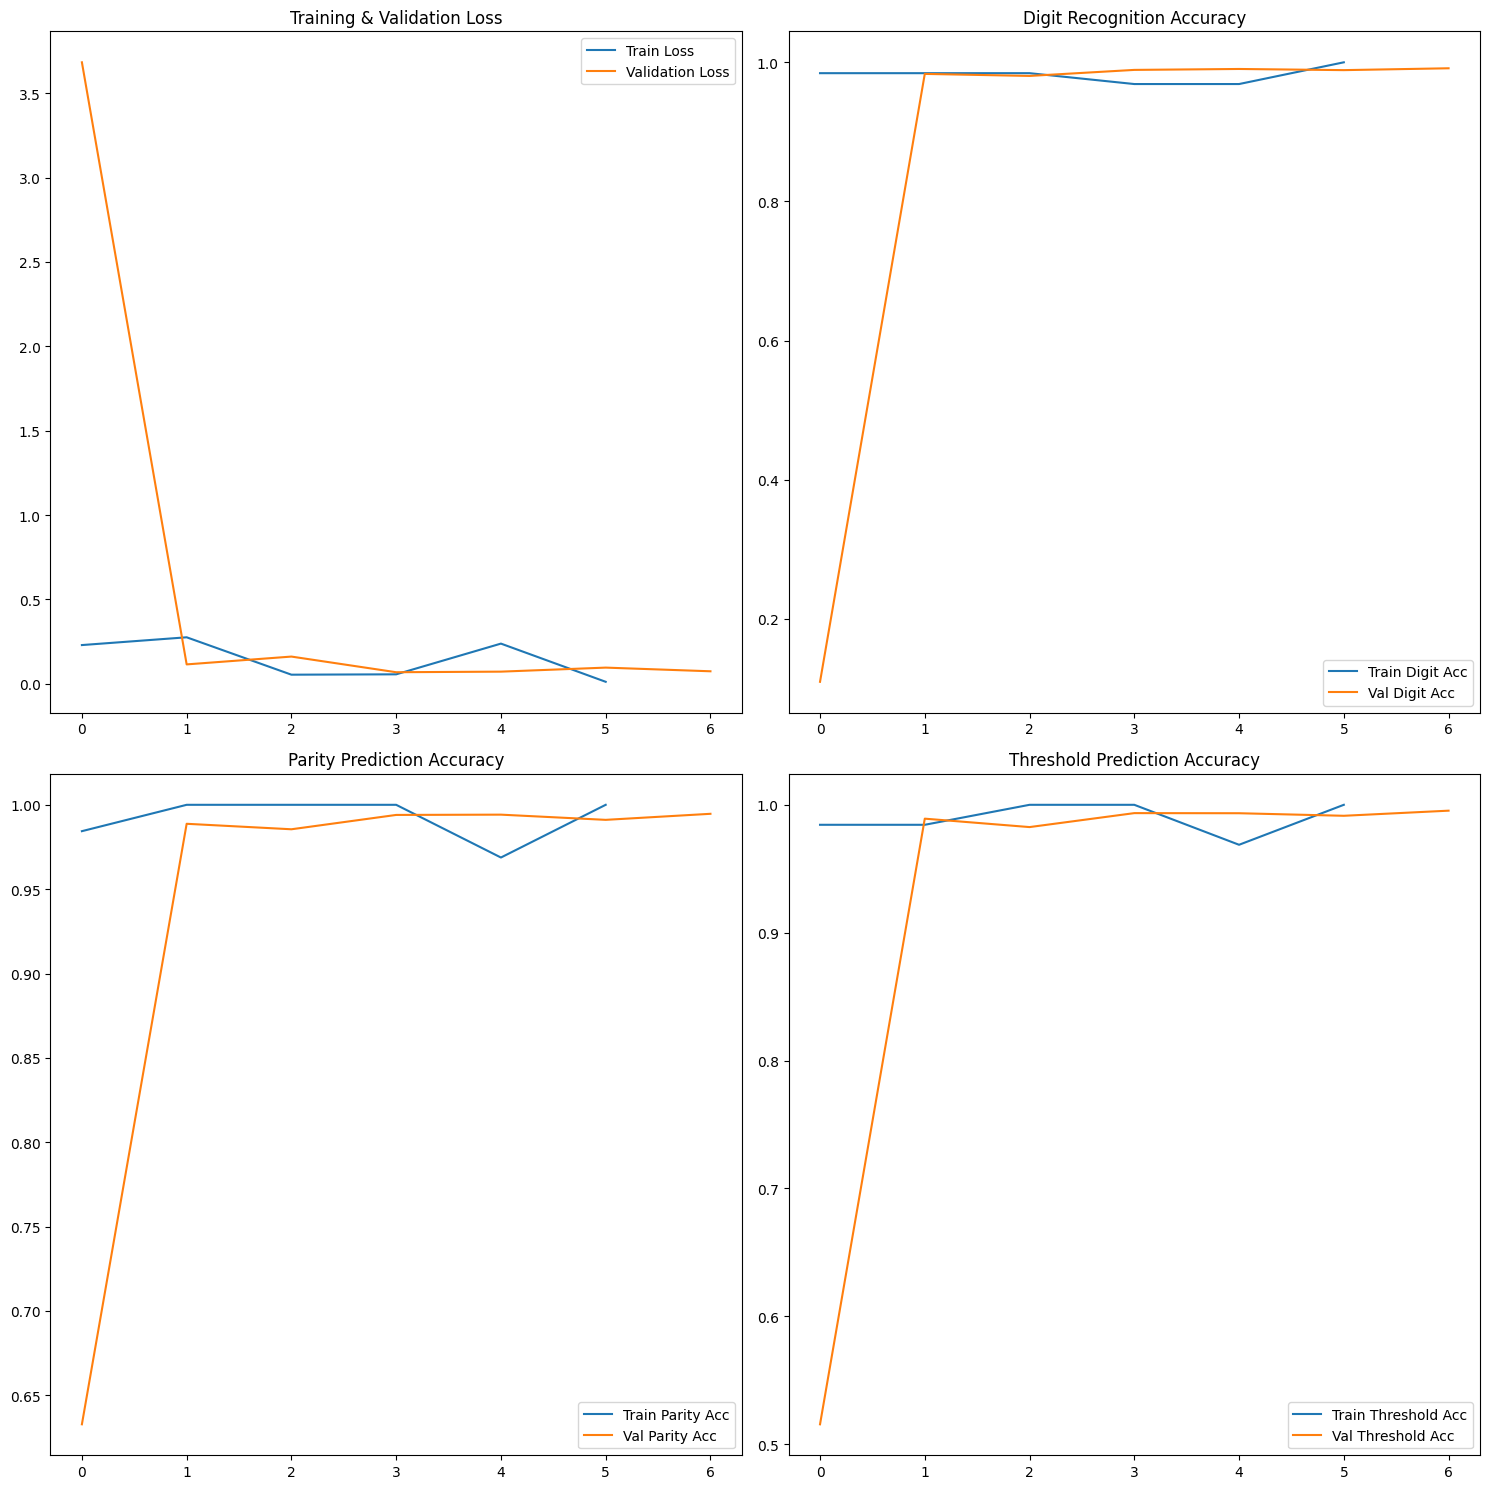

In [258]:
# Plots of the model improvement - Similar plots from the lecture notebook
plt.figure(figsize=(15, 15))

# Plot 1: Loss
plt.subplot(2, 2, 1)
plt.plot(model.train_losses, label='Train Loss')
plt.plot(model.val_losses, label='Validation Loss')
plt.legend()
plt.title('Training & Validation Loss')

# Plot 2: Digit Accuracy
plt.subplot(2, 2, 2)
plt.plot(model.train_digit_acc, label='Train Digit Acc')
plt.plot(model.val_digit_acc, label='Val Digit Acc')
plt.legend()
plt.title('Digit Recognition Accuracy')

# Plot 3: Parity Accuracy
plt.subplot(2, 2, 3)
plt.plot(model.train_parity_acc, label='Train Parity Acc')
plt.plot(model.val_parity_acc, label='Val Parity Acc')
plt.legend()
plt.title('Parity Prediction Accuracy')

# Plot 4: Threshold Accuracy
plt.subplot(2, 2, 4)
plt.plot(model.train_threshold_acc, label='Train Threshold Acc')
plt.plot(model.val_threshold_acc, label='Val Threshold Acc')
plt.legend()
plt.title('Threshold Prediction Accuracy')

plt.tight_layout()
plt.show()

In [259]:
# Save the model
torch.save(model.model.state_dict(), "experiment_5.pth")

In [260]:
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_dataset = MNISTWithParity(test_dataset)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [261]:
loaded_model = DigitParityCNN()  # use same dropout, batchnorm etc.
loaded_model.load_state_dict(torch.load("experiment_5.pth"))
loaded_model.eval()  # set to evaluation mode (disables dropout & batchnorm updates)

DigitParityCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2304, out_features=256, bias=True)
  (fc2_digit): Linear(in_features=256, out_features=10, bias=True)
  (fc2_parity): Linear(in_features=256, out_features=2, bias=True)
  (fc2_threshold): Linear(in_features=256, out_features=2, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (avgpool): AdaptiveAvg

In [262]:
# Same confusion_matrix and plot_confusion_matrix functions as in the notebook
def confusion_matrix(y_true, y_pred, num_classes):
    # Initialize a zero-filled matrix of size num_classes x num_classes
    # np.zeros creates a 2D array filled with zeros
    # The shape is (num_classes, num_classes)
    # dtype=int specifies that the array should contain integers
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    # Iterate through true and predicted labels simultaneously
    # zip(y_true, y_pred) pairs up corresponding elements from y_true and y_pred
    for true, pred in zip(y_true, y_pred):
        # Increment the count at the corresponding position in the matrix
        # true is used as the row index, pred as the column index
        # += 1 increments the count by 1 for each occurrence
        cm[true][pred] += 1
    
    # Return the completed confusion matrix
    # After all iterations, cm contains the counts of all (true, predicted) combinations
    return cm

def plot_confusion_matrix(cm, title, labels=None):
    # Create a new figure and axis with specified size
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Display the confusion matrix as an image
    # 'nearest' interpolation means no interpolation between pixels
    # plt.cm.Blues is a blue color map
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    
    # Add a colorbar to the plot, using the current axes
    ax.figure.colorbar(im, ax=ax)
    
    # Set various properties of the axis
    ax.set(
        xticks=np.arange(cm.shape[1]),  # Set x-axis ticks to match matrix columns
        yticks=np.arange(cm.shape[0]),  # Set y-axis ticks to match matrix rows
        title=title,  # Set the title of the plot
        ylabel='True label',  # Label for y-axis
        xlabel='Predicted label'  # Label for x-axis
    )
    
    # If labels are provided, use them for x and y axis
    if labels:
        ax.set_xticklabels(labels)  # Set labels for x-axis ticks
        ax.set_yticklabels(labels)  # Set labels for y-axis ticks
    
    # Rotate the tick labels on x-axis and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Calculate threshold for text color (white or black)
    # Values above thresh will be white, below will be black
    thresh = cm.max() / 2.
    
    # Add text annotations to each cell in the plot
    for i in range(cm.shape[0]):  # Iterate over rows
        for j in range(cm.shape[1]):  # Iterate over columns
            # Add text annotation for each cell
            ax.text(j, i, format(cm[i, j], 'd'),  # Position and value to display
                    ha="center", va="center",  # Center alignment
                    color="white" if cm[i, j] > thresh else "black")  # Choose text color based on cell value
    
    # Adjust the layout to prevent clipping of tick-labels
    fig.tight_layout()
    
    # Return the figure object
    return fig

In [263]:
def test_model(model, test_loader, device, criterion_digit, criterion_parity, criterion_threshold):
    model.eval()
    test_loss = 0.0
    correct_digit = correct_parity = correct_threshold = total = 0

    all_digit_preds, all_digit_labels = [], []
    all_parity_preds, all_parity_labels = [], []
    all_threshold_preds, all_threshold_labels = [], []

    misclassified_images, misclassified_labels, misclassified_preds = [], [], []
    
    test_loader_tqdm = tqdm(test_loader, desc="Testing", leave=False, ascii=True)
    
    with torch.no_grad():
        for images, (labels, parities, thresholds) in test_loader_tqdm:
            images, labels, parities, thresholds = images.to(device), labels.to(device), parities.to(device), thresholds.to(device)

            digit_outputs, parity_outputs, threshold_outputs = model(images)

            
            loss_digit = criterion_digit(digit_outputs, labels)
            loss_parity = criterion_parity(parity_outputs, parities)
            loss_threshold = criterion_threshold(threshold_outputs, thresholds)
            loss = loss_digit + loss_parity + loss_threshold
            test_loss += loss.item()
            

            _, predicted_digit = torch.max(digit_outputs, 1)
            _, predicted_parity = torch.max(parity_outputs, 1)
            _, predicted_threshold = torch.max(threshold_outputs, 1)

            total += labels.size(0)
            correct_digit += (predicted_digit == labels).sum().item()
            correct_parity += (predicted_parity == parities).sum().item()
            correct_threshold += (predicted_threshold == thresholds).sum().item()

            all_digit_preds.extend(predicted_digit.cpu().numpy())
            all_digit_labels.extend(labels.cpu().numpy())
            all_parity_preds.extend(predicted_parity.cpu().numpy())
            all_parity_labels.extend(parities.cpu().numpy())
            all_threshold_preds.extend(predicted_threshold.cpu().numpy())
            all_threshold_labels.extend(thresholds.cpu().numpy())

            for i in range(len(labels)):
                if predicted_digit[i] != labels[i] or predicted_parity[i] != parities[i] or predicted_threshold[i] != thresholds[i]:
                    misclassified_images.append(images[i].cpu())
                    misclassified_labels.append((labels[i].cpu(), parities[i].cpu(), thresholds[i].cpu()))
                    misclassified_preds.append((predicted_digit[i].cpu(), predicted_parity[i].cpu(), predicted_threshold[i].cpu()))

    test_loss /= len(test_loader)
    accuracy_digit = 100 * correct_digit / total
    accuracy_parity = 100 * correct_parity / total
    accuracy_threshold = 100 * correct_threshold / total

    print(f'Test Loss: {test_loss:.4f}, Digit Accuracy: {accuracy_digit:.2f}%, Parity Accuracy: {accuracy_parity:.2f}%, Threshold Accuracy: {accuracy_threshold:.2f}%')

    cm_digit = confusion_matrix(all_digit_labels, all_digit_preds, num_classes=10)
    cm_parity = confusion_matrix(all_parity_labels, all_parity_preds, num_classes=2)
    cm_threshold = confusion_matrix(all_threshold_labels, all_threshold_preds, num_classes=2)

    plot_confusion_matrix(cm_digit, 'Digit Confusion Matrix', labels=range(10))
    plt.figure()
    plot_confusion_matrix(cm_parity, 'Parity Confusion Matrix', labels=['Even', 'Odd'])
    plt.figure()
    plot_confusion_matrix(cm_threshold, 'Threshold Confusion Matrix', labels=['<5', '>=5'])
    plt.show()

    return test_loss, accuracy_digit, accuracy_parity, accuracy_threshold, misclassified_images, misclassified_labels, misclassified_preds


Test Loss: 0.0563, Digit Accuracy: 99.17%, Parity Accuracy: 99.50%, Threshold Accuracy: 99.41%


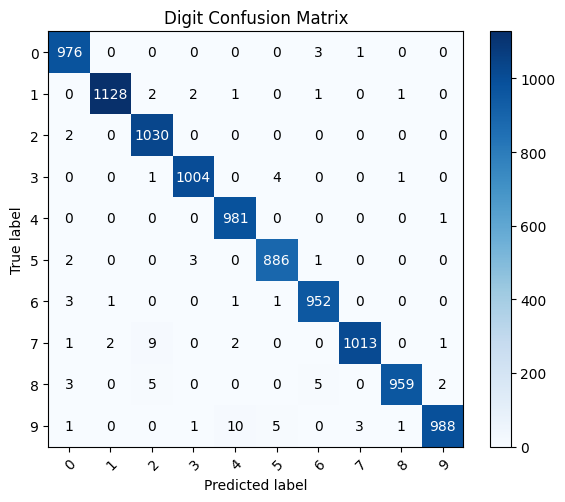

<Figure size 640x480 with 0 Axes>

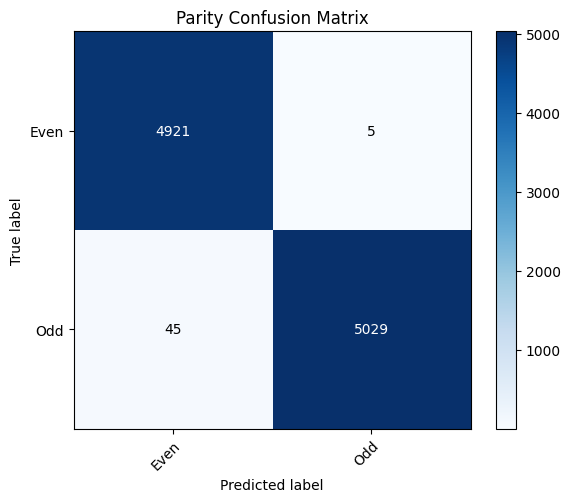

<Figure size 640x480 with 0 Axes>

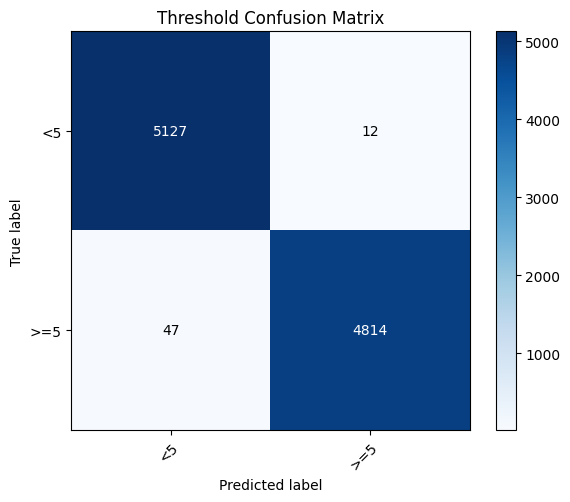

In [264]:
criterion_digit = torch.nn.CrossEntropyLoss()
criterion_parity = torch.nn.CrossEntropyLoss()
criterion_threshold = torch.nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_loss, accuracy_digit, accuracy_parity, accuracy_threshold, misclassified_images, misclassified_labels, misclassified_preds = test_model(
                                                                                                model, test_loader, device,
                                                                                                criterion_digit, criterion_parity, criterion_threshold)


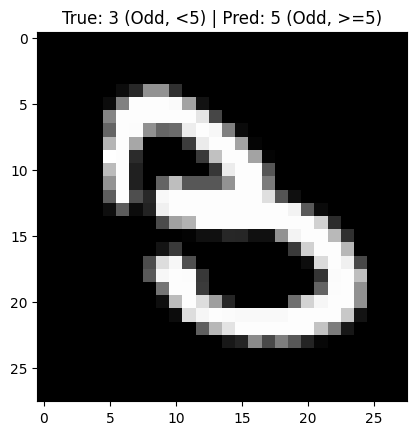

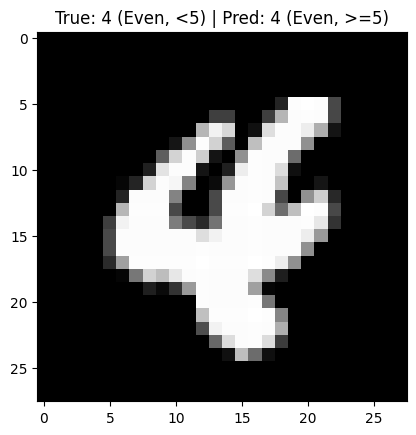

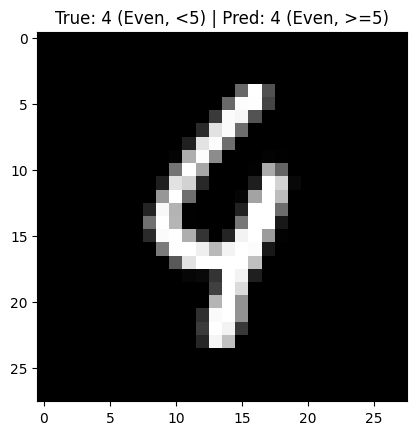

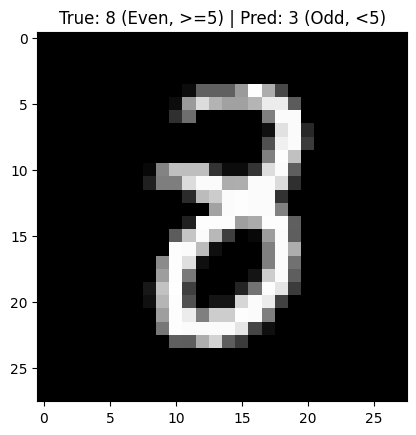

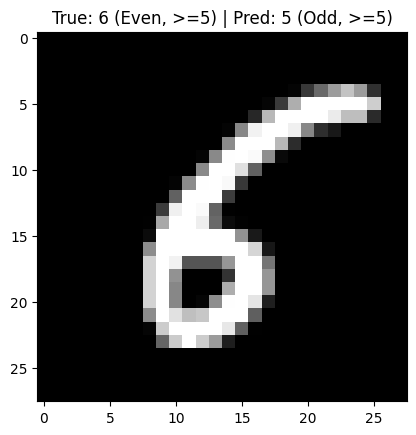

In [234]:
# Missclassified images as in the notebook. I didn't include the outputs from here since it was getting too much
def imshow(img, title):
    img = img / 2 + 0.5
    
    # Convert the image tensor to a numpy array
    npimg = img.numpy()
    
    # Transpose the dimensions to match matplotlib's expected format
    # From (channels, height, width) to (height, width, channels)
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    
    # Set the title of the plot
    plt.title(title)
    
    # Display the image
    plt.show()
    
# Show a few misclassified images
for i in range(5):  # Loop through the first 5 misclassified images
    # Extract true labels, parities, and thresholds
    true_label, true_parity, true_threshold = misclassified_labels[i]
    
    # Extract predicted labels, parities, and thresholds
    pred_label, pred_parity, pred_threshold = misclassified_preds[i]
    
    # Create strings for true and predicted labels
    true_str = f'{true_label.item()} ({["Even", "Odd"][true_parity.item()]}, {["<5", ">=5"][true_threshold.item()]})'
    pred_str = f'{pred_label.item()} ({["Even", "Odd"][pred_parity.item()]}, {["<5", ">=5"][pred_threshold.item()]})'
    
    # Display the image using the custom imshow function
    imshow(misclassified_images[i],
           f'True: {true_str} | Pred: {pred_str}')